In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

In [15]:
train = pd.read_csv('../data/train.csv')

In [16]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [18]:
train['SalePrice'].isna().sum()

np.int64(0)

<Axes: xlabel='SalePrice', ylabel='Count'>

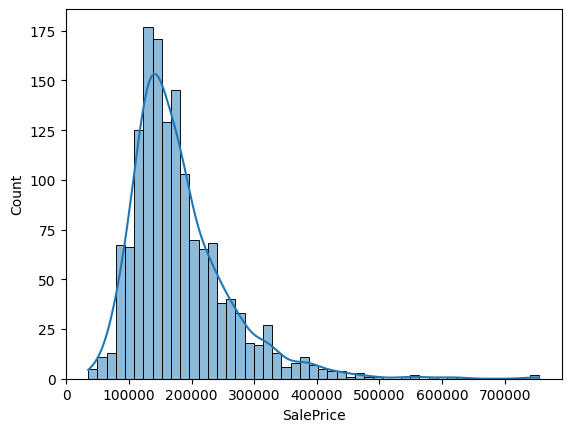

In [19]:
sns.histplot(train['SalePrice'], kde=True)

In [20]:
train['SalePrice'].skew()

np.float64(1.8828757597682129)

In [21]:
train['SalePrice_log'] = np.log(train['SalePrice'])

<Axes: xlabel='SalePrice_log', ylabel='Count'>

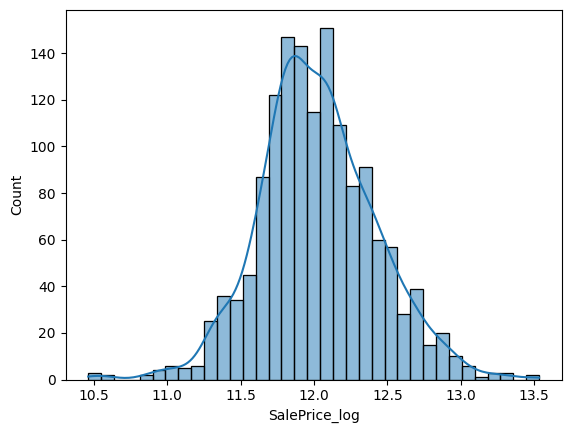

In [22]:
sns.histplot(train['SalePrice_log'], kde=True)

In [23]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

In [24]:
categoric_cols = train.select_dtypes(include=['object']).columns

C:\Users\mypci\AppData\Local\Temp\ipykernel_2908\4130061745.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_cols = train.select_dtypes(include=['object']).columns


In [25]:
corr = train[numeric_cols].corr()['SalePrice_log'].sort_values(ascending=False)

In [26]:
corr

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489449
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355878
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209044
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057329
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorc

In [30]:
train['OverallQual'].value_counts()

OverallQual
5     397
6     374
7     319
8     168
4     116
9      43
3      20
10     18
2       3
1       2
Name: count, dtype: int64

In [31]:
train['OverallQual'].isna().sum()

np.int64(0)

<Axes: xlabel='OverallQual', ylabel='Count'>

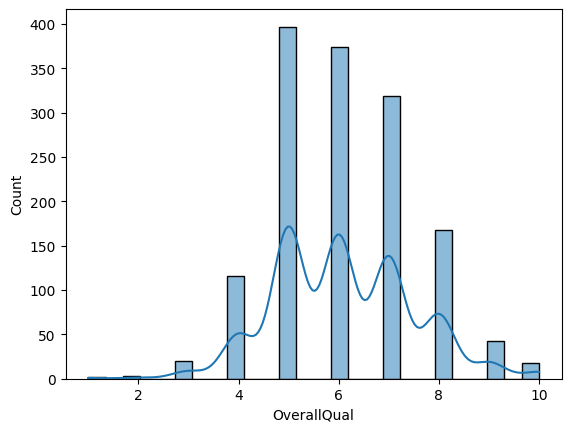

In [32]:
sns.histplot(train['OverallQual'], kde=True)

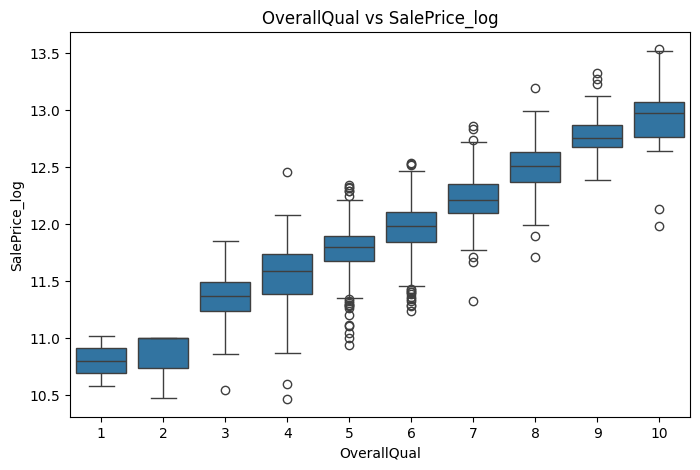

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='OverallQual', y='SalePrice_log', data=train)
plt.title('OverallQual vs SalePrice_log')
plt.show()

#### OverallQual ( highest correlation with SalePrice_log )
    - Almost nothing wrong. Normal Distribution. No Missing Values.